In [177]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (r2_score, mean_squared_error,
                             classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)


In [164]:
df = pd.read_excel(r'C:\Users\USER\Applied-Statistical-Data-Analysis-class_exercises\ASDA_2025_Group_1_Portfolio_new\48h exam\Games_final.xlsx')
print(df.head())

                       Name Platform  Year         Genre Publisher  NA_Sales  \
0                Wii Sports      Wii  2006        Sports  Nintendo     41.49   
1         Super Mario Bros.      NES  1985      Platform  Nintendo     29.08   
2            Mario Kart Wii      Wii  2008        Racing  Nintendo     15.85   
3         Wii Sports Resort      Wii  2009        Sports  Nintendo     15.75   
4  Pokemon Red/Pokemon Blue       GB  1996  Role-Playing  Nintendo     11.27   

   EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     29.02      3.77         8.46         82.74  
1      3.58      6.81         0.77         40.24  
2     12.88      3.79         3.31         35.82  
3     11.01      3.28         2.96         33.00  
4      8.89     10.22         1.00         31.37  


In [165]:
PALETTE = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12',
           '#9B59B6','#1ABC9C','#E67E22','#34495E','#E91E63',
           '#00BCD4','#8BC34A']
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

# RQ1 Which genres and platforms dominates global sales.

In [166]:
print("\n=== GENRE SUMMARY ===")
genre_summary = df.groupby('Genre').agg(
    Total_Sales   = ('Global_Sales', 'sum'),
).sort_values('Total_Sales', ascending=False)
genre_summary['Share_%'] = (genre_summary['Total_Sales'] /
                             genre_summary['Total_Sales'].sum() * 100).round(1)
print(genre_summary.round(2))


=== GENRE SUMMARY ===
              Total_Sales  Share_%
Genre                             
Action            1734.56     19.6
Sports            1319.42     14.9
Shooter           1032.62     11.7
Role-Playing       923.83     10.4
Platform           830.16      9.4
Misc               798.40      9.0
Racing             727.98      8.2
Fighting           447.05      5.0
Simulation         389.98      4.4
Puzzle             242.21      2.7
Adventure          238.28      2.7
Strategy           173.27      2.0


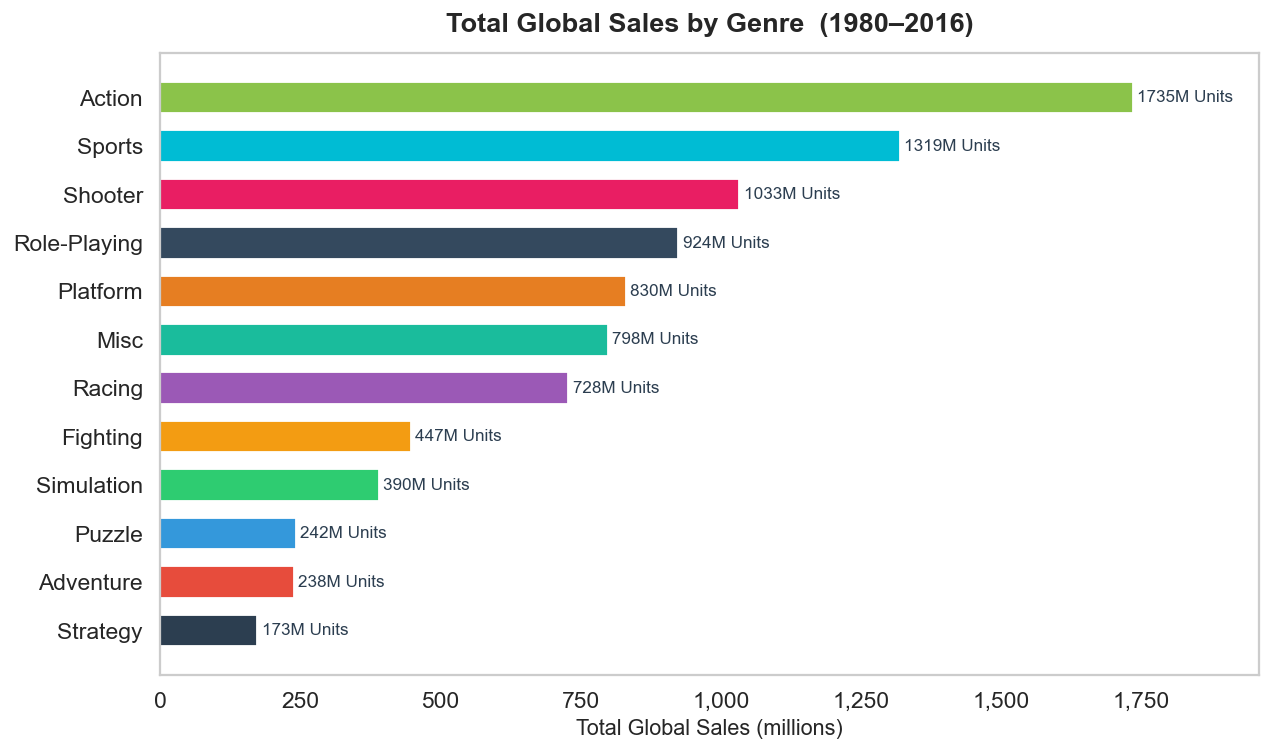

In [167]:
genre_sales = genre_summary['Total_Sales'].sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(10, 6))
colors_g = PALETTE[:len(genre_sales)]
bars = ax.barh(genre_sales.index, genre_sales.values,
               color=colors_g, edgecolor='white', height=0.65)

# value labels
for bar, val in zip(bars, genre_sales.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}M Units', va='center', fontsize=9.5, color='#2C3E50')

ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Total Global Sales by Genre  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlim(0, genre_sales.max() * 1.13)
ax.grid(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

##### Figure 1: Total global sales (millions) by genre.
Figure 1 shows total global sales by genre. Action games lead with over 1,735 million units sold, followed by Sports (1,319 M) and Shooter (1,033 M). Strategy games sit at the lower end, reflecting niche audiences.

In [168]:
print("\n=== TOP 10 PLATFORMS BY TOTAL SALES ===")
platform_summary = df.groupby('Platform').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name', 'count'),
 
).sort_values('Total_Sales', ascending=False)

print(platform_summary.head(10).round(2))


=== TOP 10 PLATFORMS BY TOTAL SALES ===
          Total_Sales  Num_Games
Platform                        
PS2           1247.51       2132
X360           972.08       1235
PS3            950.97       1304
Wii            921.10       1295
DS             818.91       2131
PS             729.89       1191
GBA            309.22        788
PSP            293.03       1198
PS4            278.10        336
PC             256.33        939


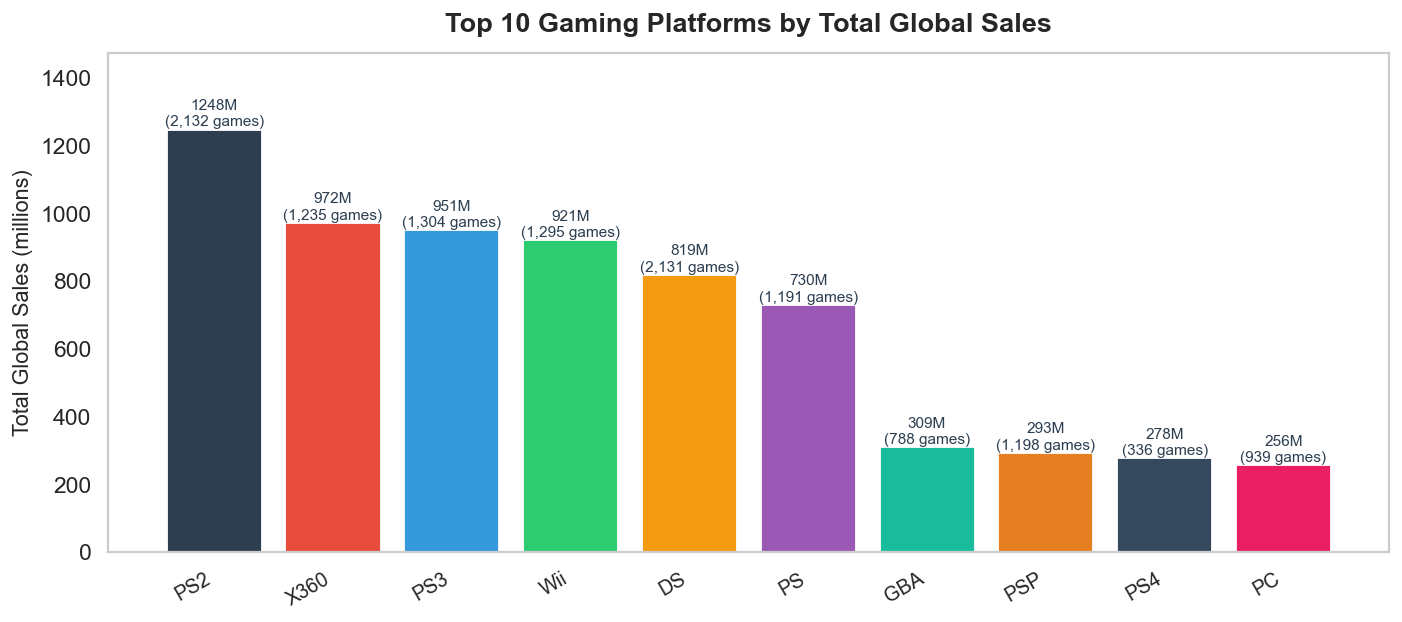

In [169]:
top10_plat = platform_summary.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(top10_plat)), top10_plat['Total_Sales'].values,
              color=PALETTE[:10], edgecolor='white')
ax.set_xticks(range(len(top10_plat)))
ax.set_xticklabels(top10_plat.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 10 Gaming Platforms by Total Global Sales',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top10_plat['Total_Sales'], top10_plat['Num_Games'])):
    ax.text(i, val + 10, f'{val:.0f}M\n({games:,} games)',
            ha='center', fontsize=8.5, color='#2C3E50')
ax.set_ylim(0, top10_plat['Total_Sales'].max() * 1.18)
ax.grid(False)
plt.tight_layout()
plt.show()

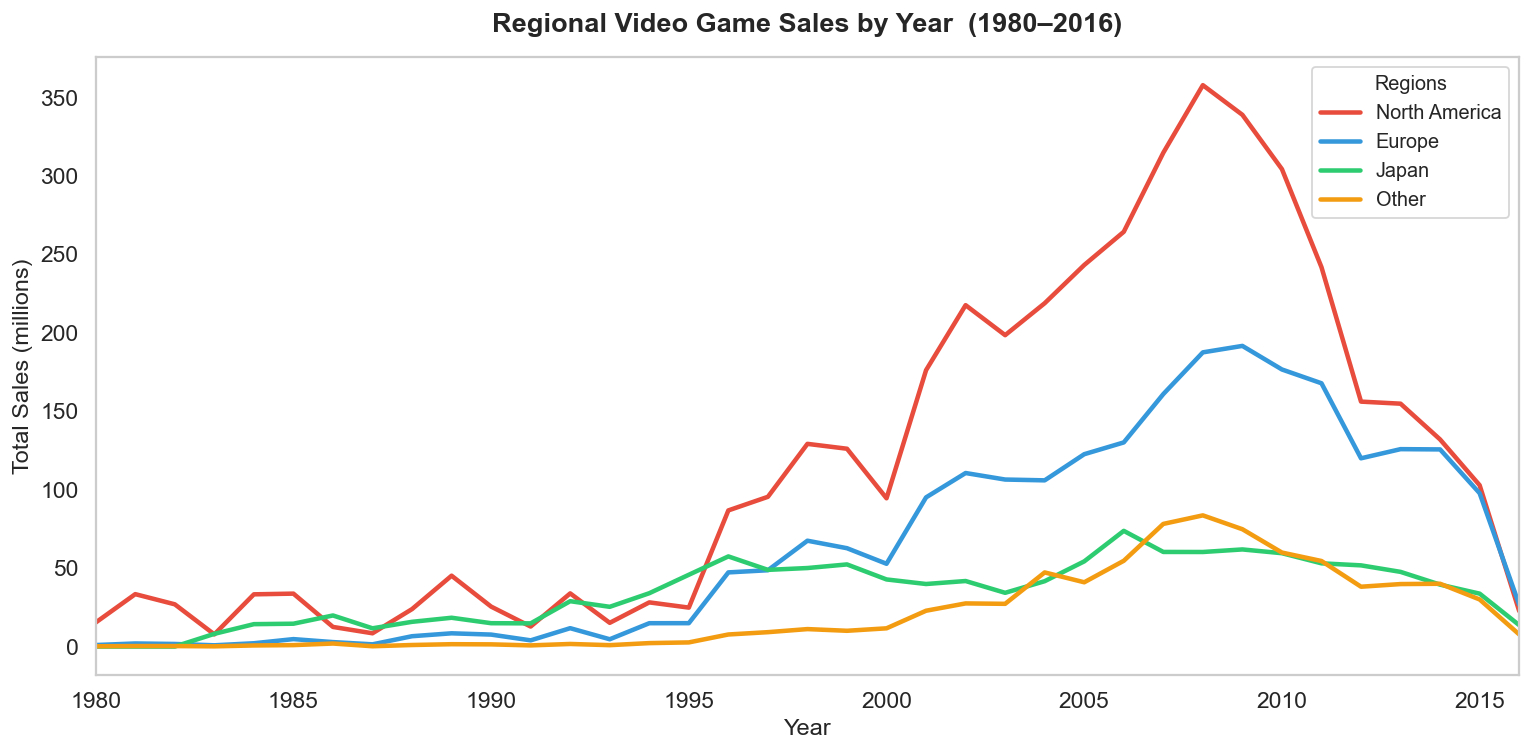

In [170]:
time_region = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()

# PLOT 
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
labels = ['North America', 'Europe', 'Japan', 'Other']

for col, color, label in zip(time_region.columns, colors, labels):
    ax.plot(time_region.index, time_region[col],
            color=color, linewidth=2.5, label=label, markersize=3)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Total Sales (millions)', fontsize=13)
ax.set_title('Regional Video Game Sales by Year  (1980–2016)',
             fontsize=15, fontweight='bold', pad=14)
ax.legend(title='Regions', fontsize=11, title_fontsize=11)
ax.set_xlim(1980, 2016)
ax.grid(False)
plt.tight_layout()
plt.show()

##### Figure 2: Annual regional sales trends (1980–2016). 
Tracks regional sales by year. The industry experienced a dramatic expansion between 2000 and 2008, peaking around 2008–2009  coinciding with the Nintendo Wii and DS boom. North America consistently leads all regions. Japan's trajectory is notably flatter, reflecting its mature and distinct domestic market. All regions decline post-2010 in the dataset, though this partly reflects data sparsity for recent years rather than an actual industry contraction.

# RQ2  Regional Market Differences

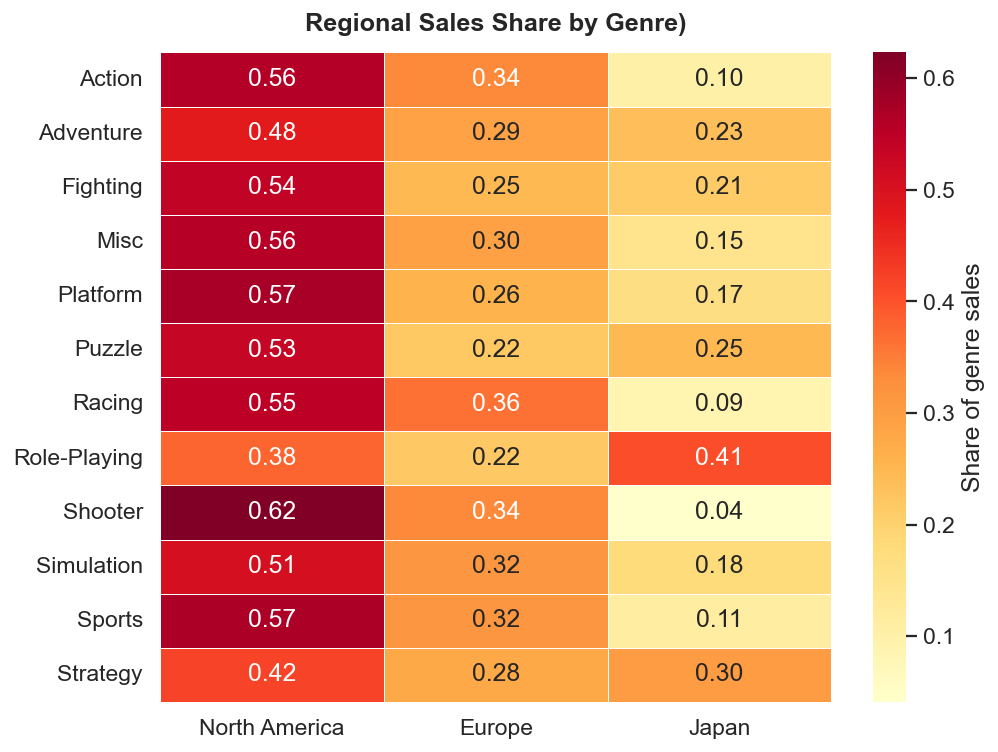

In [171]:
reg_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
reg_genre_norm = reg_genre.div(reg_genre.sum(axis=1), axis=0)   # row-wise share
reg_genre_norm.columns = ['North America', 'Europe', 'Japan']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    reg_genre_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Share of genre sales'}
)
ax.set_title('Regional Sales Share by Genre)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##### To test whether regional tastes differ, we computed each region's share of sales within each genre. Figure 3 visualises these shares as a heatmap.
Several patterns stand out. Japan commands a much higher share of Role-Playing genre
sales (typically >40%) compared to its modest share in Shooter or Sports genres. This is
consistent with Japan's historical strength in JRPG franchises (Final Fantasy, Dragon Quest,
Pokemon). North America dominates Shooter and Sports genres, both reflecting culturally
embedded preferences (American football simulations, first-person shooters). Europe's share is
broadly proportional across genres, with a slight over-index in Racing and Fighting.
To quantify regional similarity, we computed Pearson correlations between regional sales
vectors at the game level. NA and EU sales are strongly correlated (r = 0.77), indicating broadly
shared Western preferences. JP sales are much less correlated with NA (r = 0.33) and EU (r =
0.29), confirming that Japan constitutes a distinctly different market.

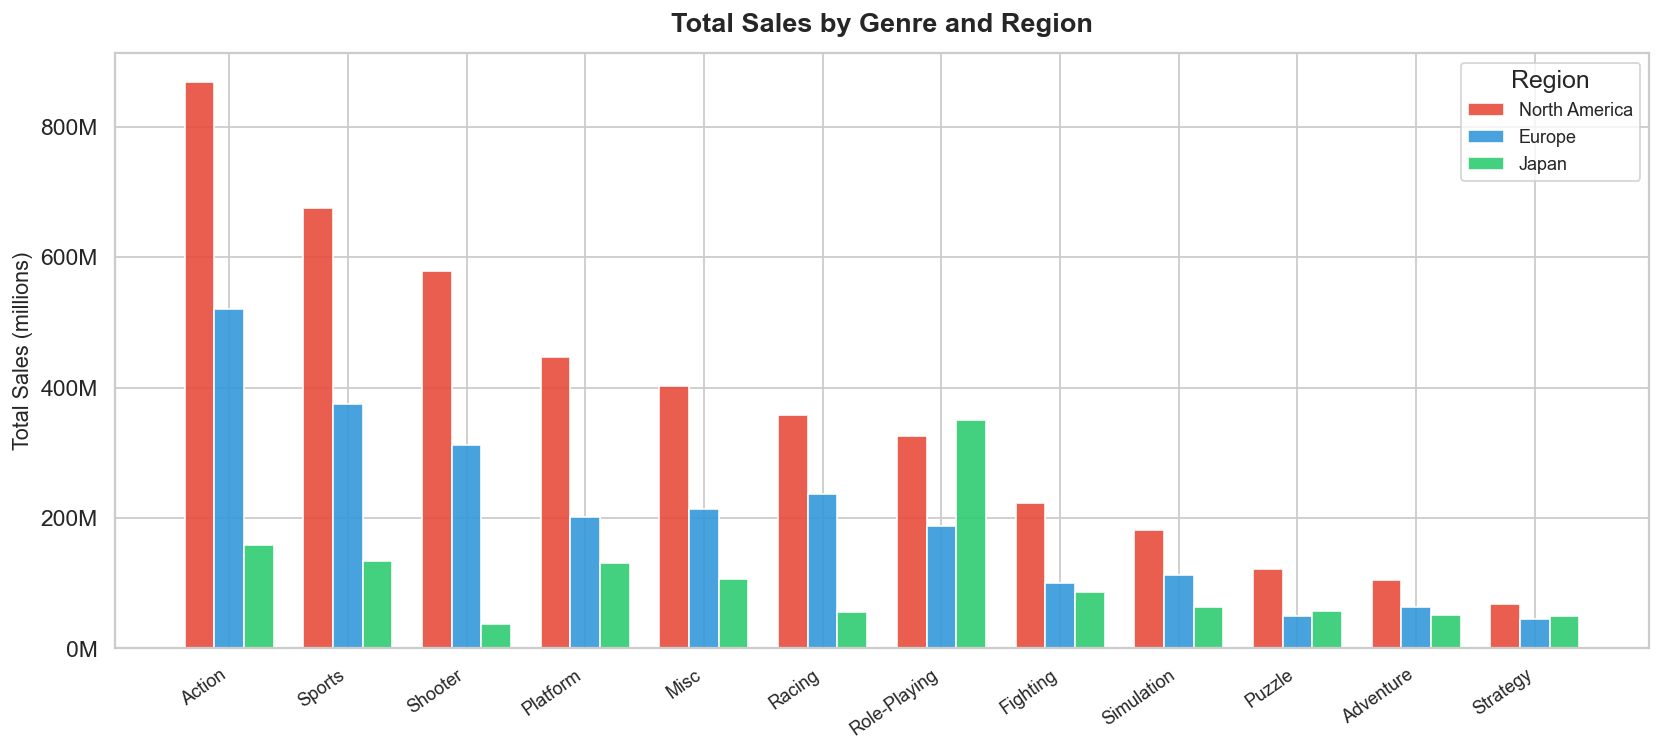

In [172]:
reg_genre_abs = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
reg_genre_abs.columns = ['North America', 'Europe', 'Japan']
reg_genre_abs = reg_genre_abs.sort_values('North America', ascending=False)

x      = np.arange(len(reg_genre_abs))
width  = 0.25
colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color) in enumerate(zip(reg_genre_abs.columns, colors)):
    ax.bar(x + i * width, reg_genre_abs[col], width,
           label=col, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(reg_genre_abs.index, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_title('Total Sales by Genre and Region', fontsize=15, fontweight='bold', pad=12)
ax.legend(title='Region', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
plt.tight_layout()
plt.show()

# RQ3  Publisher Market Concentration

In [173]:
pub = df.groupby('Publisher').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name',         'count'),
    Avg_Sales   = ('Global_Sales', 'mean'),
    First_Year  = ('Year',         'min'),
    Last_Year   = ('Year',         'max')
).sort_values('Total_Sales', ascending=False)
pub['Lifespan'] = pub['Last_Year'] - pub['First_Year']

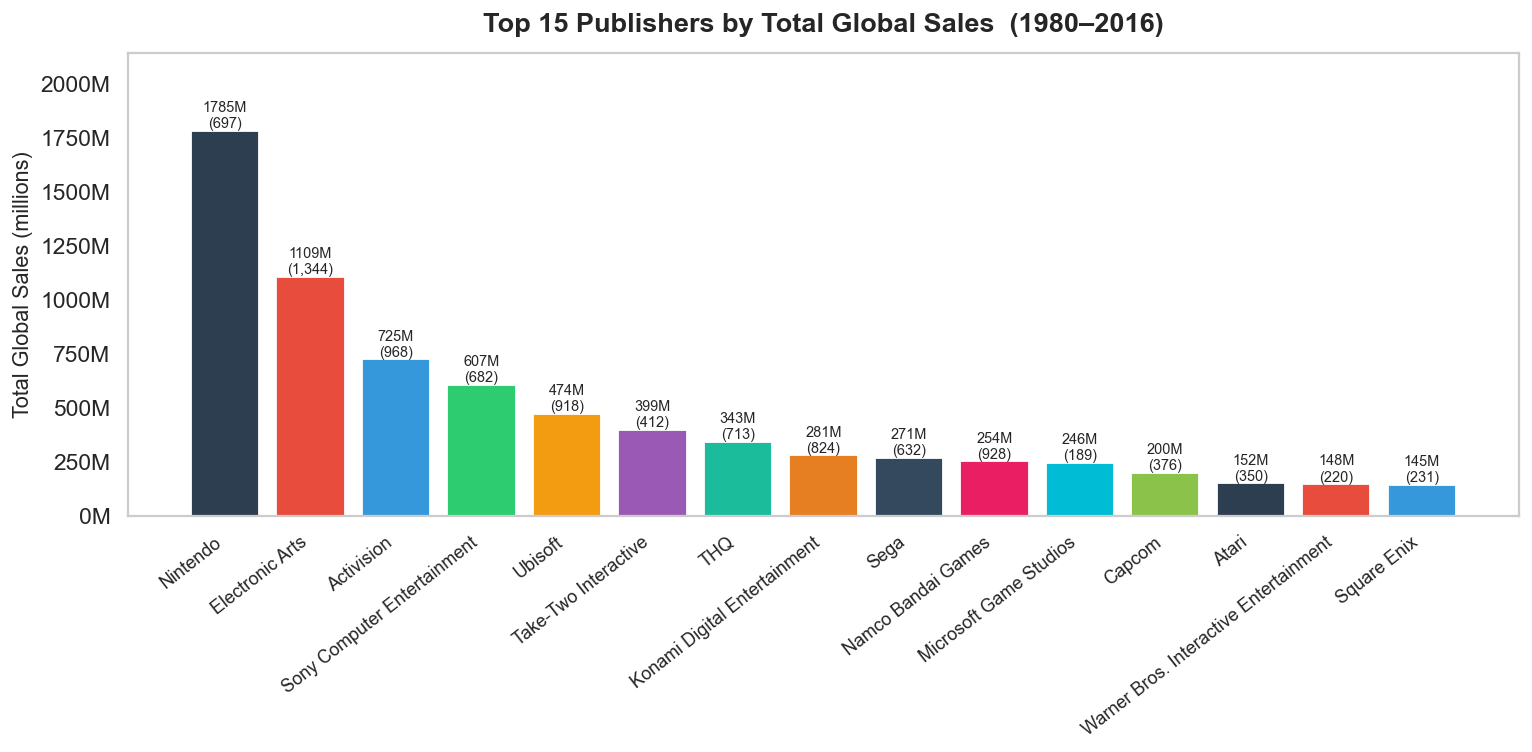

In [174]:
top15 = pub.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(top15)), top15['Total_Sales'].values,
              color=PALETTE[:15], edgecolor='white')
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 15 Publishers by Total Global Sales  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top15['Total_Sales'], top15['Num_Games'])):
    ax.text(i, val + 12, f'{val:.0f}M\n({games:,})', ha='center', fontsize=8)
ax.set_ylim(0, top15['Total_Sales'].max() * 1.20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
ax.grid(False)
plt.tight_layout()
plt.show()

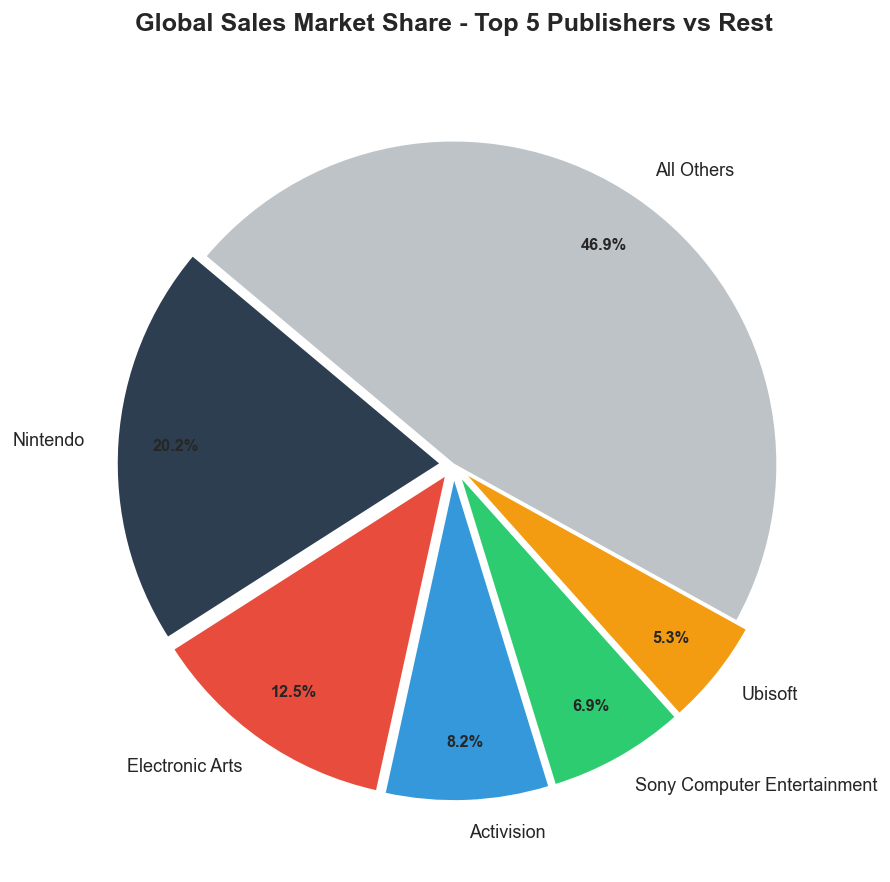

In [175]:
top5_sales  = pub.head(5)['Total_Sales']
rest_sales  = pub.iloc[5:]['Total_Sales'].sum()
pie_labels  = list(top5_sales.index) + ['All Others']
pie_values  = list(top5_sales.values) + [rest_sales]
pie_colors  = PALETTE[:5] + ['#BDC3C7']
explode     = [0.04] * 5 + [0]

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', explode=explode,
    startangle=140, pctdistance=0.82,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Global Sales Market Share - Top 5 Publishers vs Rest',
             fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()



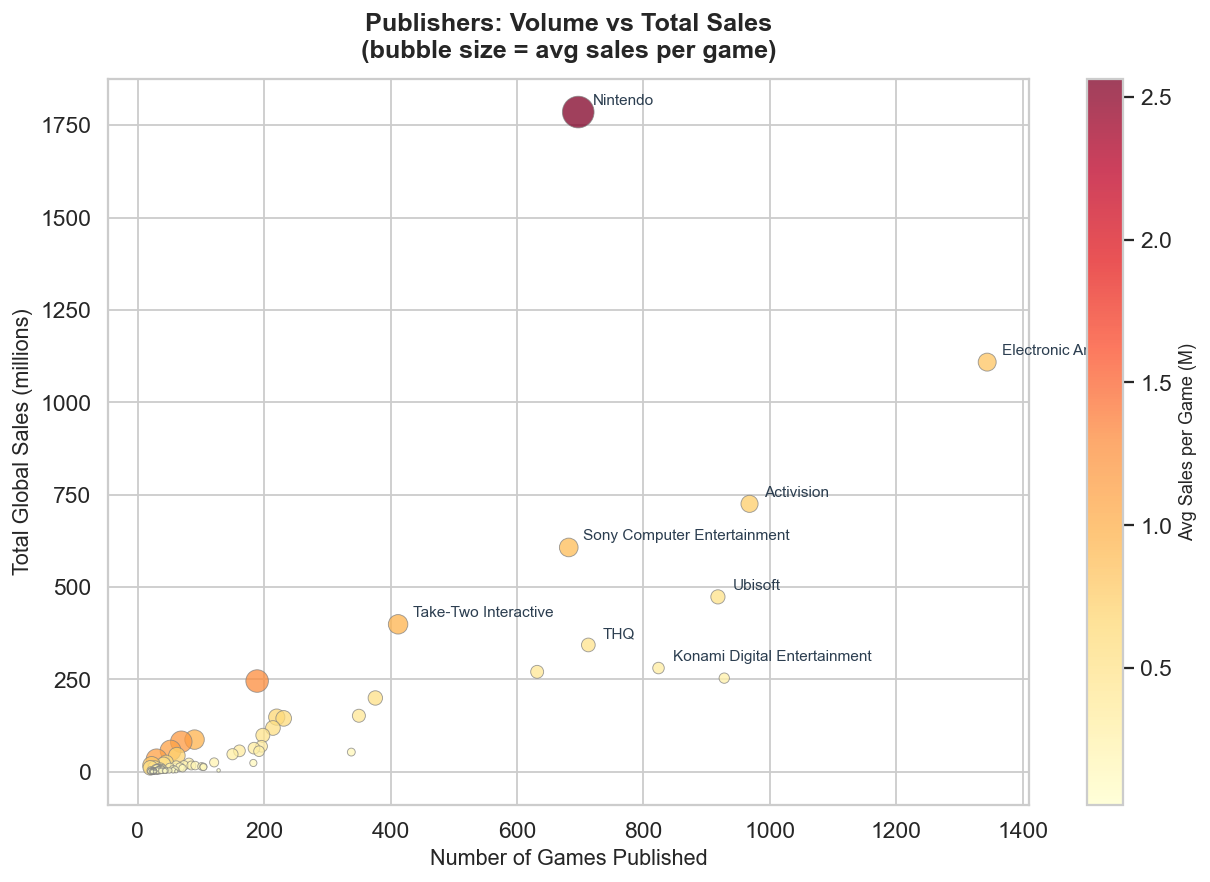

In [176]:
pub_plot = pub[pub['Num_Games'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    pub_plot['Num_Games'], pub_plot['Total_Sales'],
    s=pub_plot['Avg_Sales'] * 120,        # bubble size = avg sales
    c=pub_plot['Avg_Sales'],
    cmap='YlOrRd', alpha=0.75, edgecolors='grey', linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Sales per Game (M)', fontsize=10)

# label top publishers
for pub_name, row in pub_plot.nlargest(8, 'Total_Sales').iterrows():
    ax.annotate(pub_name,
                xy=(row['Num_Games'], row['Total_Sales']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, color='#2C3E50')

ax.set_xlabel('Number of Games Published', fontsize=12)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Publishers: Volume vs Total Sales\n(bubble size = avg sales per game)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## Statistical tests 

##### Q1: Is genre preference independent of region? 


Genre Independence from Region  (Chi-Square)
  Chi-Square statistic : 2083.99
  Degrees of freedom   : 22
  p-value              : 0.0000e+00
  Cramér's V           : 0.2528  (moderate association)
  Result               : SIGNIFICANT ✓


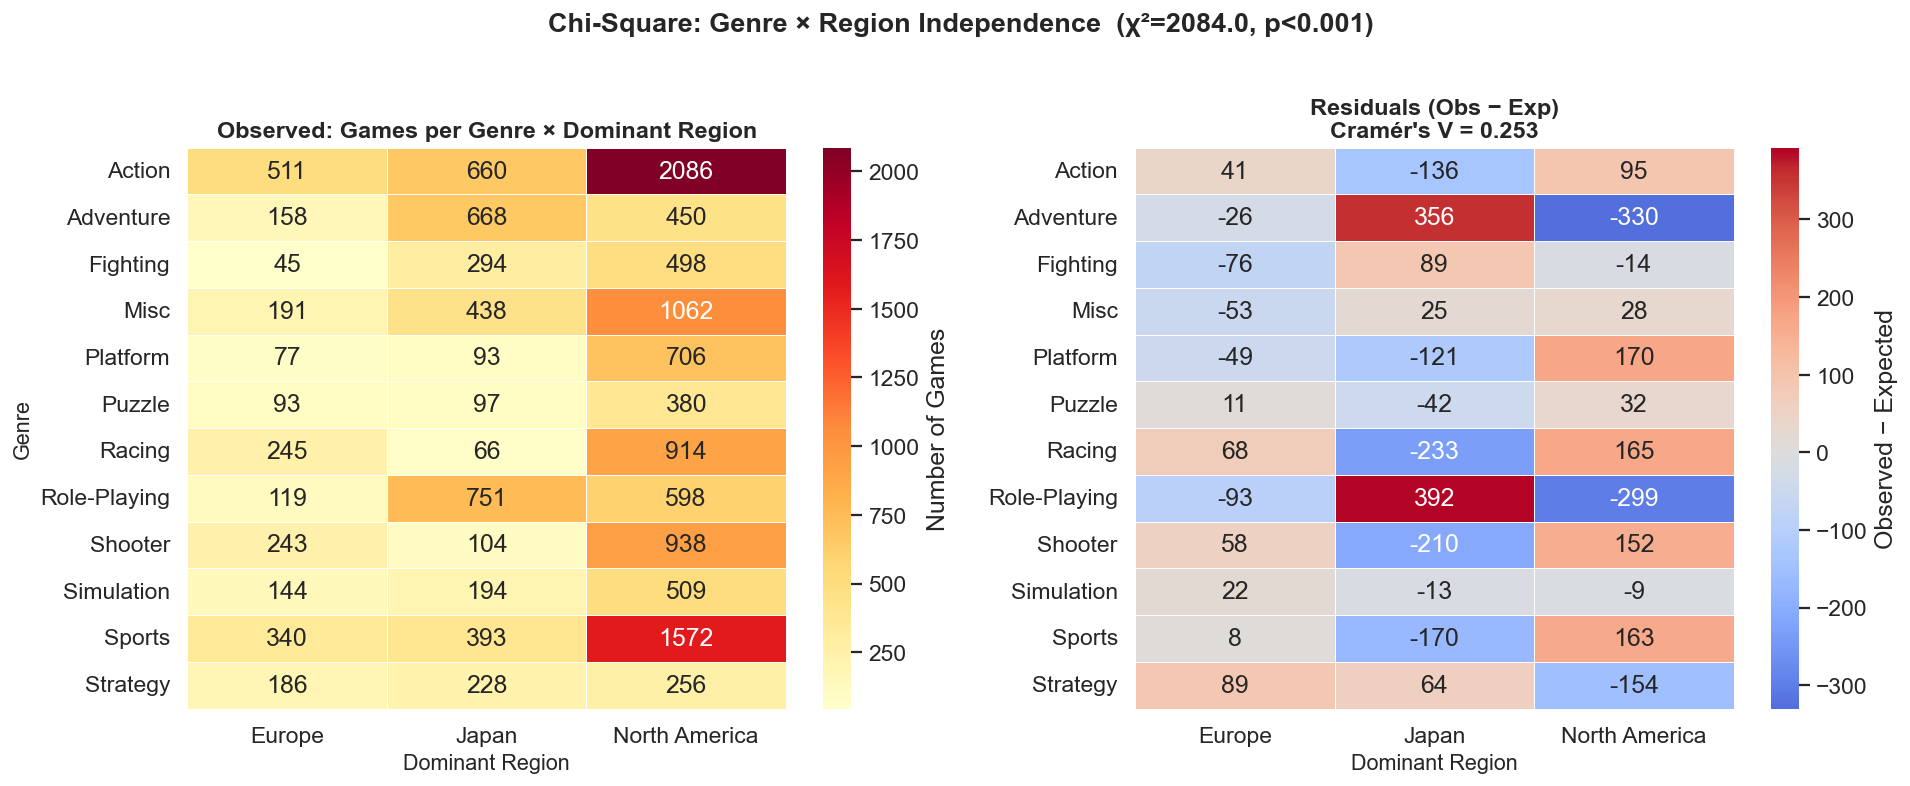

In [182]:

# we perform Chi-Square Test here to test if genre preference is independent of region Because Both variables are categorical (genre × region)
# H0     : Genre choice is independent of region
# H1     : Genre preference depends on region
results = {}
print("=" * 60)
print("Genre Independence from Region  (Chi-Square)")
print("=" * 60)

# classify each game's "dominant region"
reg_cols = ['NA_Sales','EU_Sales','JP_Sales']
df['Dom_Region'] = df[reg_cols].idxmax(axis=1).map({
    'NA_Sales':'North America',
    'EU_Sales':'Europe',
    'JP_Sales':'Japan'
})
# only keep games where dominant region is clear (>0)
df_chi = df[df[reg_cols].max(axis=1) > 0].copy()

contingency = pd.crosstab(df_chi['Genre'], df_chi['Dom_Region'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

# Cramér's V (effect size for chi-square)
n_chi = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_chi * (min(contingency.shape) - 1)))

print(f"  Chi-Square statistic : {chi2:.2f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {p_chi:.4e}")
print(f"  Cramér's V           : {cramers_v:.4f}  "
      f"({'strong' if cramers_v>0.3 else 'moderate' if cramers_v>0.1 else 'weak'} association)")
print(f"  Result               : {'SIGNIFICANT ✓' if p_chi<0.05 else 'Not significant'}")
results['RQ-T4'] = {'test':'Chi-Square','stat':chi2,'p':p_chi,'sig':p_chi<0.05}

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# heatmap of observed counts
ax = axes[0]
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label':'Number of Games'})
ax.set_title('Observed: Games per Genre × Dominant Region',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dominant Region', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)

# residuals heatmap (observed - expected)
residuals = contingency.values - expected
res_df    = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns)
ax = axes[1]
sns.heatmap(res_df, annot=True, fmt='.0f', cmap='coolwarm',
            ax=ax, linewidths=0.5, center=0,
            cbar_kws={'label':'Observed − Expected'})
ax.set_title(f'Residuals (Obs − Exp)\nCramér\'s V = {cramers_v:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dominant Region', fontsize=12)
ax.set_ylabel('')

plt.suptitle(f'Chi-Square: Genre × Region Independence  (χ²={chi2:.1f}, p<0.001)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()